In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
data = pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")

In [3]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]

data_train = data[1000:m].T
Y_train = data_train[0] 
X_train = data_train[1:n]
X_train = X_train / 255


In [5]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

def ReLu(Z):
    return np.maximum(0, Z)

def softmax(Z):
    Z_norm = Z - np.max(Z, 0, keepdims=True)
    return np.exp(Z_norm) / np.sum(np.exp(Z_norm), 0, keepdims=True)

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLu(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def deriv_ReLU(Z):
    return Z > 0

def back_prop(Z1, A1, Z2, A2, W2, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)
     
    dZ2 = A2 - one_hot_Y
    dW2 = 1/m * dZ2.dot(A1.T)
    db2 = 1/m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)

    dW1 =  1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)

    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1

    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2 

    return W1, b1, W2, b2

In [6]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size



def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2, = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if (i % 10 == 0):
            print("Iteration: ", i)
            print("Accuracy: ", get_accuracy(get_predictions(A2), Y))
    return W1, b1, W2, b2
        

In [7]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 500, 0.1)


Iteration:  0
[1 3 0 ... 0 1 0] [1 8 2 ... 8 5 0]
Accuracy:  0.12226829268292683
Iteration:  10
[1 9 1 ... 5 5 0] [1 8 2 ... 8 5 0]
Accuracy:  0.23946341463414633
Iteration:  20
[0 9 1 ... 0 5 0] [1 8 2 ... 8 5 0]
Accuracy:  0.2978292682926829
Iteration:  30
[0 9 1 ... 0 5 0] [1 8 2 ... 8 5 0]
Accuracy:  0.3488292682926829
Iteration:  40
[0 9 6 ... 0 5 0] [1 8 2 ... 8 5 0]
Accuracy:  0.39209756097560977
Iteration:  50
[0 9 6 ... 0 5 0] [1 8 2 ... 8 5 0]
Accuracy:  0.4410487804878049
Iteration:  60
[0 5 6 ... 5 5 0] [1 8 2 ... 8 5 0]
Accuracy:  0.4922682926829268
Iteration:  70
[1 2 6 ... 5 5 0] [1 8 2 ... 8 5 0]
Accuracy:  0.5403658536585366
Iteration:  80
[1 2 6 ... 5 5 0] [1 8 2 ... 8 5 0]
Accuracy:  0.575390243902439
Iteration:  90
[1 2 6 ... 8 5 0] [1 8 2 ... 8 5 0]
Accuracy:  0.6044146341463414
Iteration:  100
[1 2 6 ... 8 5 0] [1 8 2 ... 8 5 0]
Accuracy:  0.6266585365853659
Iteration:  110
[1 2 6 ... 8 5 0] [1 8 2 ... 8 5 0]
Accuracy:  0.6459024390243903
Iteration:  120
[1 2 2 ..

Prediction:  [1]
Label:  1


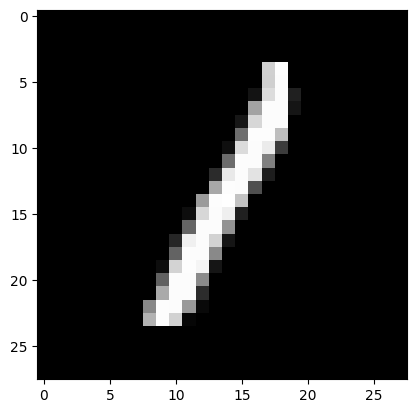

Prediction:  [8]
Label:  8


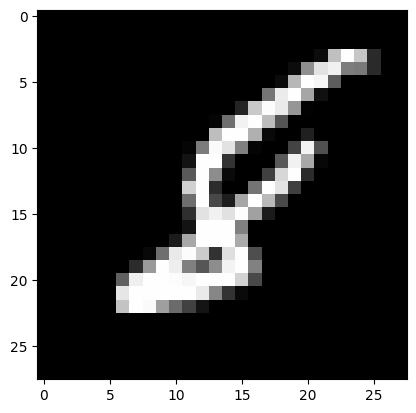

Prediction:  [2]
Label:  2


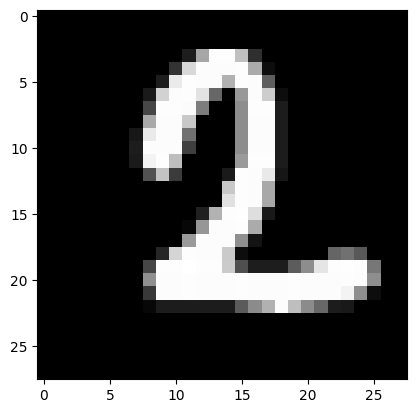

In [8]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)